In [ ]:
### datasets
# time_series_covid19_confirmed_global.csv
# time_series_covid19_deaths_global.csv

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
pd.read_csv('/content/time_series_covid19_confirmed_global.csv')
pd.read_csv('/content/time_series_covid19_deaths_global.csv')


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,5708,5708,5708,5708,5708,5708,5708,5708,5708,5708
285,NaN,Winter Olympics 2022,39.904200,116.407400,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
286,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,2159,2159,2159,2159,2159,2159,2159,2159,2159,2159
287,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,4019,4019,4022,4022,4023,4023,4024,4024,4024,4024


In [ ]:
# can we have multiple index? Let's try
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
a=pd.Series([1,2,3,4,5,6,7,8],index=index_val)
a

,0
"(cse, 2019)",1
"(cse, 2020)",2
"(cse, 2021)",3
"(cse, 2022)",4
"(ece, 2019)",5
"(ece, 2020)",6
"(ece, 2021)",7
"(ece, 2022)",8


In [ ]:
# how to create multiindex object
# 1. pd.MultiIndex.from_tuples()
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
multiindex.levels[1]
# 2. pd.MultiIndex.from_product()
pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]])

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [ ]:
s = pd.Series([1,2,3,4,5,6,7,8],index=multiindex)
s

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [ ]:
s["cse"]

,0
2019,1
2020,2
2021,3
2022,4


In [ ]:
# The solution -> multiindex series(also known as Hierarchical Indexing)
# multiple index levels within a single index

In [ ]:
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex=pd.MultiIndex.from_tuples(index_val)
multiindex.levels[1]
# 2. pd.MultiIndex.from_product()

pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]])

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [ ]:
# creating a series with multiindex object
# first way
pd.Series([1,2,3,4,5,6,7,8,],index=pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]]))
# second way
pd.Series([1,2,3,4,5,6,7,8,],index=multiindex)
# third way
s=pd.Series([1,2,3,4,5,6,7,8,],index=pd.MultiIndex.from_tuples(index_val))

In [ ]:
# how to fetch items from such a series
s['cse']

,0
2019,1
2020,2
2021,3
2022,4


In [ ]:
# unstack
temp=s.unstack()
temp

,2019,2020,2021,2022
cse,1,2,3,4
ece,5,6,7,8


In [ ]:
temp.stack()

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [ ]:
# Then what was the point of multiindex series?

In [ ]:
# multiindex dataframe

In [ ]:
branch_df=pd.DataFrame([
    [1,2],
    [3,4],
    [5,6],
    [7,8],
    [9,10],
    [11,12],
    [13,14],
    [15,16]
], index=multiindex,
   columns=['avg_package','students']
)

In [ ]:
branch_df

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [ ]:
# Are columns really different from index?

In [ ]:
# multiindex df from columns perspective

In [ ]:
branch_df2=pd.DataFrame([
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
],index=[2019,2020,2021,2022],
  columns=pd.MultiIndex.from_product([['Delhi','Mumbia'],['avg_package','students']])
)

In [ ]:
branch_df2

Delhi               Mumbia         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

In [ ]:
branch_df2.iloc[::3,0]

Delhi               Mumbia
     avg_package students avg_package
2019           1        2           0
2022           7        8           0

In [ ]:
# Multiindex df in terms of both cols and index

branch_df3 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

branch_df3

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [ ]:
branch_df3.iloc[[0,4]]

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
ece 2019           9       10           0        0

In [ ]:
branch_df3.unstack()

delhi                                             mumbai            \
    avg_package                students                avg_package             
           2019 2020 2021 2022     2019 2020 2021 2022        2019 2020 2021   
cse           1    3    5    7        2    4    6    8           0    0    0   
ece           9   11   13   15       10   12   14   16           0    0    0   

                                  
         students                 
    2022     2019 2020 2021 2022  
cse    0        0    0    0    0  
ece    0        0    0    0    0

# **pivot**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [ ]:
df =sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
df.groupby('sex')[['total_bill']].mean()

,total_bill
sex,
Male,20.744076
Female,18.056897


In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
df.groupby(['sex',"smoker"]).agg({
    "total_bill": ["sum","mean"],
}).reset_index()

sex smoker total_bill           
                        sum       mean
0    Male    Yes    1337.07  22.284500
1    Male     No    1919.75  19.791237
2  Female    Yes     593.27  17.977879
3  Female     No     977.68  18.105185

In [ ]:
# by defult avg function aplly
df.pivot_table(index='sex',columns='smoker', values='total_bill')

smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [ ]:
df.pivot_table(index="sex", columns='smoker',values=['total_bill','tip','size'])

size                 tip           total_bill           
smoker       Yes        No       Yes        No        Yes         No
sex                                                                 
Male    2.500000  2.711340  3.051167  3.113402  22.284500  19.791237
Female  2.242424  2.592593  2.931515  2.773519  17.977879  18.105185

In [ ]:
df.pivot_table(index=["sex"],columns=["smoker"],values='total_bill', aggfunc="sum",margins=True)

smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [ ]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'size':'mean','tip':'max','total_bill':'sum'})

size                                               tip  \
day                Thur              Fri              Sat       Sun  Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner Lunch   
sex    smoker                                                               
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  5.00   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  6.70   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  5.00   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  5.17   

                                                total_bill                \
day                    Fri           Sat    Sun       Thur           Fri   
time          Dinner Lunch Dinner Dinner Dinner      Lunch Dinner  Lunch   
sex    smoker                                                              
Male   Yes       NaN  2.20   4.73  10.00    6.5     191.71   0.00  34.16   
       No        NaN   NaN   3.50   9.00    6.0     369.73   0.00   0.00   
Female Yes       NaN  3.48   4.30   6.50    4.0     134.53   0.00  39.78   
       No        3.0  3.00   3.25   4.67    5.2     381.58  18.78  15.98   

                                                   
day                     Sat           Sun          
time           Dinner Lunch  Dinner Lunch  Dinner  
sex    smoker                                      
Male   Yes     129.46   0.0  589.62   0.0  392.12  
       No       34.95   0.0  637.73   0.0  877.34  
Female Yes      48.80   0.0  304.00   0.0   66.16  
       No       22.75   0.0  247.05   0.0  291.54

In [ ]:
df.pivot_table(index='sex',columns=['day','time'],values='total_bill')

day          Thur               Fri                   Sat        Sun
time        Lunch Dinner      Lunch     Dinner     Dinner     Dinner
sex                                                                 
Male    18.714667    NaN  11.386667  23.487143  20.802542  21.887241
Female  16.648710  18.78  13.940000  14.310000  19.680357  19.872222

In [ ]:
df2=pd.read_csv("/content/expense_data.csv")

In [ ]:
df2.drop(columns=['Subcategory'],inplace=True)
df2.drop(columns=['Note.1'],inplace=True)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Note            273 non-null    object 
 4   INR             277 non-null    float64
 5   Income/Expense  277 non-null    object 
 6   Amount          277 non-null    float64
 7   Currency        277 non-null    object 
 8   Account.1       277 non-null    float64
dtypes: float64(3), object(6)
memory usage: 19.6+ KB


In [ ]:
df2['Date']=pd.to_datetime(df2['Date'])

In [ ]:
df2['Month']=df2['Date'].dt.month_name()

In [ ]:
temp=df2[['Date','Month','Account','Category','Note',"INR","Income/Expense","Amount","Currency",]]

In [ ]:
temp.head()

,Date,Month,Account,Category,Note,INR,Income/Expense,Amount,Currency
0,2022-03-02 10:11:00,March,CUB - online payment,Food,Brownie,50.0,Expense,50.0,INR
1,2022-03-02 10:11:00,March,CUB - online payment,Other,To lended people,300.0,Expense,300.0,INR
2,2022-03-01 19:50:00,March,CUB - online payment,Food,Dinner,78.0,Expense,78.0,INR
3,2022-03-01 18:56:00,March,CUB - online payment,Transportation,Metro,30.0,Expense,30.0,INR
4,2022-03-01 18:22:00,March,CUB - online payment,Food,Snacks,67.0,Expense,67.0,INR


<Axes: xlabel='Month'>

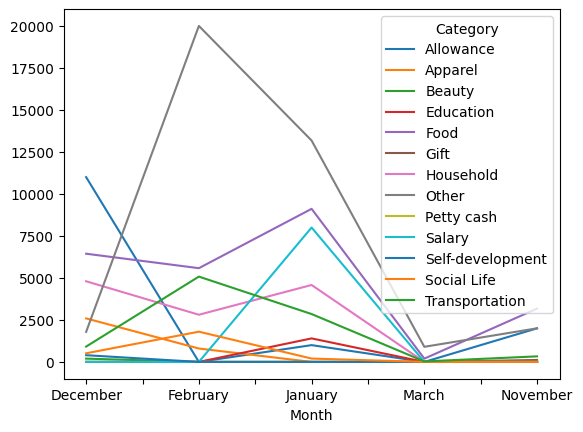

In [ ]:
temp.groupby(['Month','Category'])['INR'].sum().unstack().fillna(0).plot()

<Axes: xlabel='Month'>

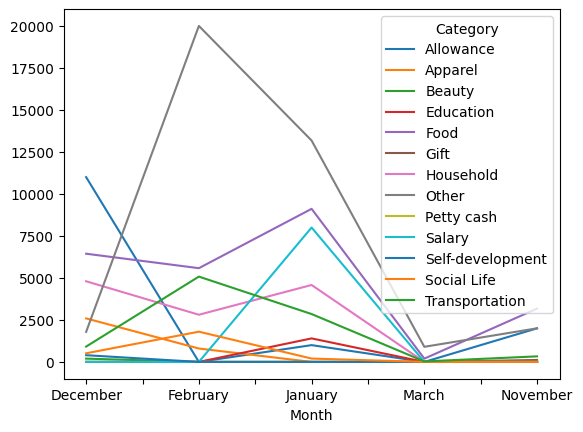

In [ ]:
temp.pivot_table(index='Month',columns='Category',values="INR", aggfunc="sum" ,fill_value=0).plot()